In [20]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from ydata_profiling.config import Settings

# Dataset Generation

In [3]:
db = 'northwind.db'
conn = sqlite3.connect(db)

In [4]:
all_data = pd.read_sql_query(
    "SELECT * FROM sqlite_master;",
    conn
)

# Show DataFields
all_data

,type,name,tbl_name,rootpage,sql
0,table,Categories,Categories,2,CREATE TABLE [Categories]\n( [CategoryID]...
1,table,sqlite_sequence,sqlite_sequence,3,"CREATE TABLE sqlite_sequence(name,seq)"
2,table,CustomerCustomerDemo,CustomerCustomerDemo,28,CREATE TABLE [CustomerCustomerDemo](\n [Cust...
3,index,sqlite_autoindex_CustomerCustomerDemo_1,CustomerCustomerDemo,29,None
4,table,CustomerDemographics,CustomerDemographics,30,CREATE TABLE [CustomerDemographics](\n [Cust...
5,index,sqlite_autoindex_CustomerDemographics_1,CustomerDemographics,31,None
6,table,Customers,Customers,32,CREATE TABLE [Customers]\n( [CustomerID] ...
7,index,sqlite_autoindex_Customers_1,Customers,33,None
8,table,Employees,Employees,37,CREATE TABLE [Employees]\n( [EmployeeID] ...
9,table,EmployeeTerritories,EmployeeTerritories,67,CREATE TABLE [EmployeeTerritories](\n [Emplo...


In [5]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

# Show Table Schemas
tables

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [6]:
customers_df = pd.read_sql_query(
    "SELECT * FROM Customers;",
    conn
)

customers_df.head()

,CustomerID,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,Western Europe,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,Central America,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,Central America,05023,Mexico,(5) 555-3932,None
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,British Isles,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,Northern Europe,S-958 22,Sweden,0921-12 34 65,0921-12 34 67


In [7]:
orders_df = pd.read_sql_query(
    'SELECT * FROM Orders;',
    conn
)

orders_df.head()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2016-07-08,2016-08-05,2016-07-12,2,25.00,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2016-07-08,2016-08-05,2016-07-15,1,20.25,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2016-07-09,2016-08-06,2016-07-11,2,36.25,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium


In [8]:
order_details_df = pd.read_sql_query(
    'SELECT * FROM "Order Details";',
    conn 
)

order_details_df.head()

,OrderID,ProductID,UnitPrice,Quantity,Discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [9]:
products_df = pd.read_sql_query(
    'SELECT * FROM Products;',
    conn
)

products_df.head()

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


In [10]:
orders_enriched_df = orders_df.merge(order_details_df, on='OrderID', how='left'
    ).merge(products_df, on='ProductID', how='left'
    ).merge(customers_df, on='CustomerID', how='left')

orders_enriched_df.head()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,...,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,...,Vins et alcools Chevalier,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11
1,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,...,Vins et alcools Chevalier,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11
2,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,...,Vins et alcools Chevalier,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11
3,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,...,Toms Spezialitäten,Karin Josephs,Marketing Manager,Luisenstr. 48,Münster,Western Europe,44087,Germany,0251-031259,0251-035695
4,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,...,Toms Spezialitäten,Karin Josephs,Marketing Manager,Luisenstr. 48,Münster,Western Europe,44087,Germany,0251-031259,0251-035695


In [11]:
df_cleaned = (
    orders_enriched_df
    .drop(columns=[c for c in orders_enriched_df.columns if c.endswith('_y')])
    .rename(columns=lambda x: x.replace('_x', ''))
    # Important to keep data (if not ML).
    # .drop(columns=['Country', 'ShipCountry'], errors='ignore')
)

df_cleaned.head()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,...,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,...,Vins et alcools Chevalier,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11
1,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,...,Vins et alcools Chevalier,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11
2,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,...,Vins et alcools Chevalier,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11
3,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,...,Toms Spezialitäten,Karin Josephs,Marketing Manager,Luisenstr. 48,Münster,Western Europe,44087,Germany,0251-031259,0251-035695
4,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,...,Toms Spezialitäten,Karin Josephs,Marketing Manager,Luisenstr. 48,Münster,Western Europe,44087,Germany,0251-031259,0251-035695


In [12]:
df_cleaned['OrderRevenue'] = (df_cleaned['UnitPrice'] - (df_cleaned['UnitPrice'] * df_cleaned['Discount'])) * df_cleaned['Quantity']
df_cleaned = df_cleaned.reset_index(names='LineItem')
df_cleaned.head()

,LineItem,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,...,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax,OrderRevenue
0,0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,...,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11,168.0
1,1,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,...,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11,98.0
2,2,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,...,Paul Henriot,Accounting Manager,59 rue de l'Abbaye,Reims,Western Europe,51100,France,26.47.15.10,26.47.15.11,174.0
3,3,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,...,Karin Josephs,Marketing Manager,Luisenstr. 48,Münster,Western Europe,44087,Germany,0251-031259,0251-035695,167.4
4,4,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,...,Karin Josephs,Marketing Manager,Luisenstr. 48,Münster,Western Europe,44087,Germany,0251-031259,0251-035695,1696.0


# Category Revenue Variability

In [19]:
# Category Revenue Variability
# Pivot Table
pivot_df = df_cleaned.pivot_table(
    index='CategoryID', 
    values='OrderRevenue', 
    aggfunc=['count', 'sum', 'mean', 'median', 'std', 'min', 'max']
)

pivot_df.columns = [f"{col[0]}_{col[1]}" for col in pivot_df.columns]
pivot_df['CV'] = pivot_df['std_OrderRevenue'] / pivot_df['mean_OrderRevenue']
pivot_df['Skewness'] = df_cleaned.groupby('CategoryID')['OrderRevenue'].skew()
pivot_df = pivot_df.sort_values(by='CV', ascending=False)

# Heatmap
styled_pivot = (pivot_df.style
    .background_gradient(subset=['CV'], cmap='Reds')
    .background_gradient(subset=['Skewness'], cmap='YlOrBr')
    .format(precision=2)
    .set_caption("Northwind Dataset: Category Revenue Variability & Usability Audit")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), 
                                                     ('color', 'white'), 
                                                     ('font-family', 'fivethirtyeight')]}])
)

styled_pivot

,count_OrderRevenue,sum_OrderRevenue,mean_OrderRevenue,median_OrderRevenue,std_OrderRevenue,min_OrderRevenue,max_OrderRevenue,CV,Skewness
CategoryID,,,,,,,,,
1,95083,92163184.18,969.29,399.00,2087.54,4.50,15810.00,2.15,4.01
3,102784,66337803.06,645.41,418.80,704.56,7.30,5268.00,1.09,2.26
6,47335,64881147.97,1370.68,873.00,1444.81,7.45,9903.20,1.05,1.49
8,94912,49921604.17,525.98,380.00,521.98,4.80,3125.00,0.99,2.28
5,55400,28568530.34,515.68,378.00,433.23,7.00,4322.50,0.84,1.18
4,79233,58018116.78,732.25,609.00,583.98,2.50,6050.00,0.80,0.87
7,39548,32701119.88,826.87,660.00,649.36,10.00,6042.00,0.79,0.89
2,94988,55795126.78,587.39,494.00,439.73,10.00,2565.00,0.75,1.16


/var/folders/_r/z8mg07nd3h1df8wp3z78yjdr0000gn/T/ipykernel_57914/2561581770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


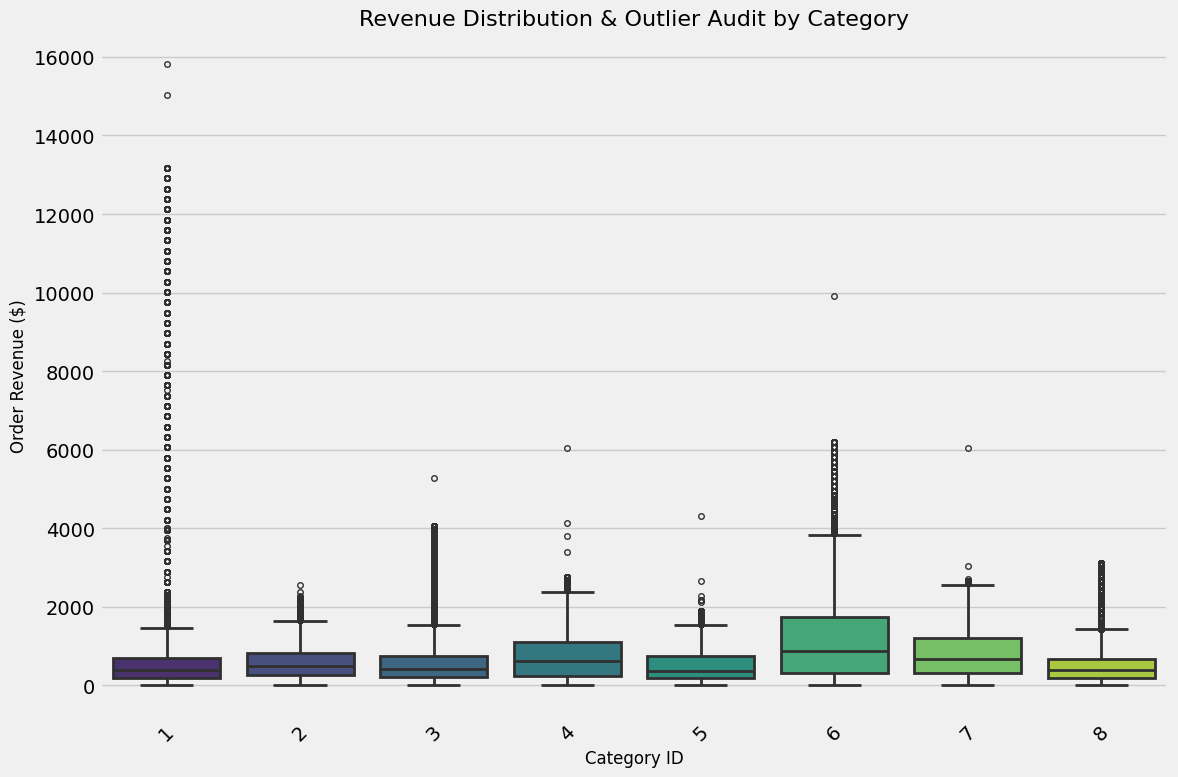

In [ ]:
# Category Revenue Variability
with plt.style.context("fivethirtyeight"):
    plt.figure(figsize=(12, 8))
    
    sns.boxplot(
        data=df_cleaned, 
        x='CategoryID', 
        y='OrderRevenue',
        palette='viridis',
        linewidth=2,
        fliersize=4
    )
    
    plt.title('Revenue Distribution & Outlier Audit by Category', fontsize=16)
    plt.xlabel('Category ID', fontsize=12)
    plt.ylabel('Order Revenue ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig('category_revenue_boxplot.png')

# Customer Segment Variability

In [ ]:
# Customer Segment Variability
geo_levels = ['Region', 'Country', 'City']
geo_pivots = {}

for level in geo_levels:
    pivot = df_cleaned.pivot_table(
        index=level,
        values='OrderRevenue',
        aggfunc=['count', 'sum', 'mean', 'median', 'std']
    )
    
    pivot.columns = [f"{col[0]}_{col[1]}" for col in pivot.columns]
    pivot['CV'] = pivot['std_OrderRevenue'] / pivot['mean_OrderRevenue']
    pivot['Skewness'] = df_cleaned.groupby(level)['OrderRevenue'].skew()
    
    styled = (pivot.sort_values(by='CV', ascending=False).style
        .background_gradient(subset=['CV'], cmap='Reds')
        .background_gradient(subset=['Skewness'], cmap='YlOrBr')
        .format(precision=2)
        .set_caption(f"Geographic Audit: {level} Revenue Variability")
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])
    )
    
    geo_pivots[level] = styled

In [23]:
geo_pivots['Region']

,count_OrderRevenue,sum_OrderRevenue,mean_OrderRevenue,median_OrderRevenue,std_OrderRevenue,CV,Skewness
Region,,,,,,,
Central America,33783,24802282.44,734.16,460.00,1073.39,1.46,5.84
Western Europe,181137,133676505.70,737.99,462.50,1078.93,1.46,5.79
British Isles,52497,38691537.09,737.02,462.00,1076.74,1.46,5.70
South America,107566,79460258.01,738.71,462.00,1078.42,1.46,5.74
Scandinavia,18906,13901257.43,735.28,462.00,1061.95,1.44,5.81
North America,104890,76803232.30,732.23,460.00,1057.34,1.44,5.74
Eastern Europe,6448,4738465.22,734.87,462.25,1059.90,1.44,5.78
Northern Europe,25998,19008073.87,731.14,460.00,1053.75,1.44,5.67
Southern Europe,64775,47559649.83,734.23,460.00,1057.49,1.44,5.63


In [24]:
geo_pivots['Country']

,count_OrderRevenue,sum_OrderRevenue,mean_OrderRevenue,median_OrderRevenue,std_OrderRevenue,CV,Skewness
Country,,,,,,,
Belgium,12598,9425760.44,748.19,469.85,1129.24,1.51,6.08
Argentina,19161,14233566.76,742.84,463.10,1104.99,1.49,5.89
Austria,13449,9908284.14,736.73,450.00,1087.80,1.48,5.59
Venezuela,26240,19424911.97,740.28,456.00,1086.83,1.47,5.68
UK,46055,33959254.80,737.36,462.00,1079.00,1.46,5.72
Mexico,33783,24802282.44,734.16,460.00,1073.39,1.46,5.84
France,72426,53323305.76,736.25,462.00,1073.78,1.46,5.74
Finland,12497,9210006.79,736.98,463.20,1074.72,1.46,5.88
Germany,69371,51195766.82,738.00,465.00,1074.23,1.46,5.80


In [25]:
geo_pivots['City']

,count_OrderRevenue,sum_OrderRevenue,mean_OrderRevenue,median_OrderRevenue,std_OrderRevenue,CV,Skewness
City,,,,,,,
Bruxelles,6391,4815829.33,753.53,468.00,1159.91,1.54,6.07
Reims,5754,4332214.28,752.90,465.00,1152.38,1.53,5.97
Reggio Emilia,5736,4223241.67,736.27,460.00,1100.56,1.49,5.58
San Cristóbal,6601,4841324.41,733.42,448.00,1091.47,1.49,5.65
Brandenburg,6266,4621173.90,737.50,466.41,1097.41,1.49,5.92
Buenos Aires,19161,14233566.76,742.84,463.10,1104.99,1.49,5.89
Portland,12354,9129715.63,739.01,456.00,1099.02,1.49,5.85
Barquisimeto,7293,5437438.34,745.57,462.00,1108.36,1.49,5.78
Luleå,6530,4833398.53,740.18,462.00,1097.53,1.48,5.89


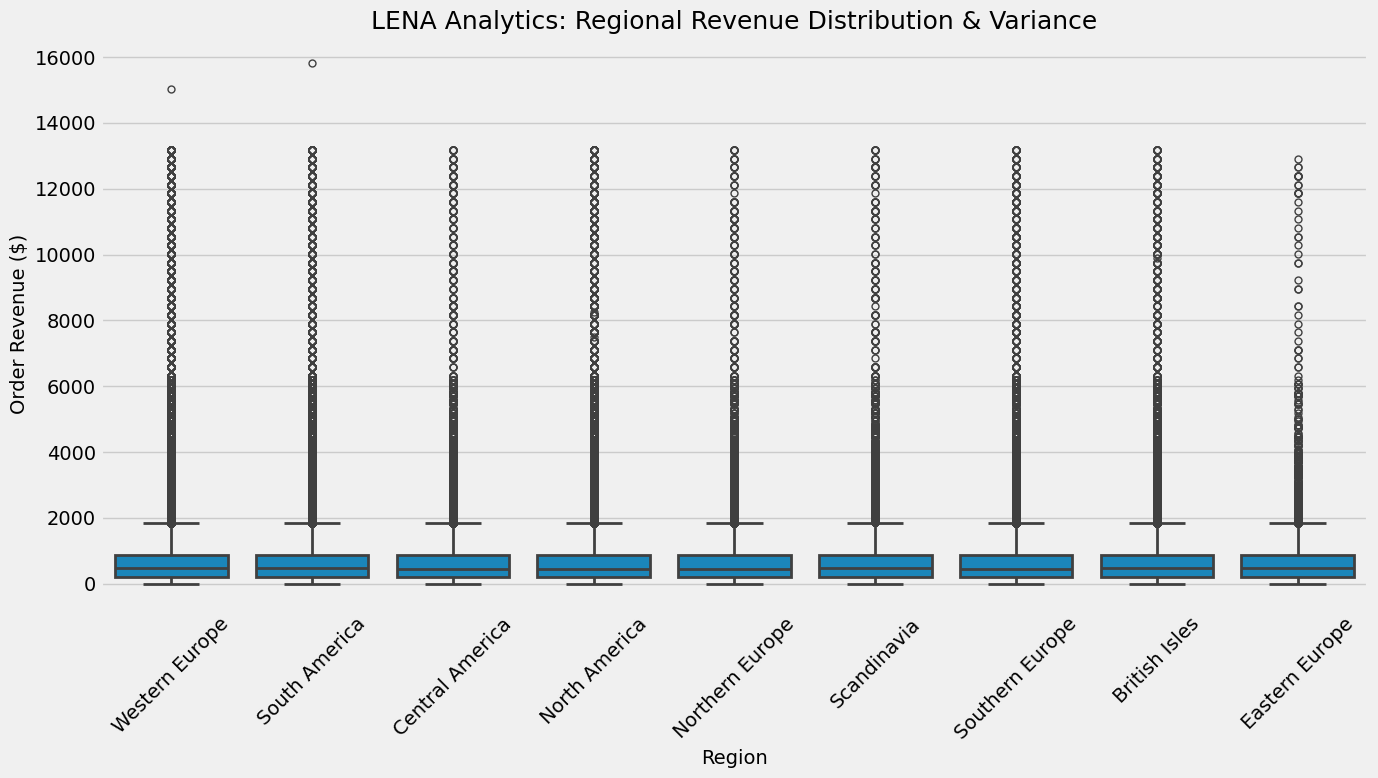

In [28]:
with plt.style.context("fivethirtyeight"):
    plt.figure(figsize=(14, 8))
    
    sns.boxplot(
        data=df_cleaned, 
        x='Region', 
        y='OrderRevenue',
        linewidth=2,
        fliersize=5
    )
    
    plt.title('LENA Analytics: Regional Revenue Distribution & Variance', fontsize=18)
    plt.xlabel('Region', fontsize=14)
    plt.ylabel('Order Revenue ($)', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

# Bias and Architectural Integrity

In [32]:
# Bias and Architectural Integrity
df_cleaned['Discontinued'] = pd.to_numeric(df_cleaned['Discontinued'], errors='coerce').fillna(0).astype(int)
status_pivot = df_cleaned.pivot_table(
    index='CategoryID',
    values='Discontinued',
    aggfunc=['count', 'sum']
)

status_pivot.columns = ['Total_Products', 'Discontinued_Count']
status_pivot['Active_Count'] = status_pivot['Total_Products'] - status_pivot['Discontinued_Count']
status_pivot['%_Discontinued'] = (status_pivot['Discontinued_Count'] / status_pivot['Total_Products']) * 100
status_pivot = status_pivot.sort_values(by='%_Discontinued', ascending=False)
styled_status = (status_pivot.style
    .background_gradient(subset=['%_Discontinued'], cmap='Reds')
    .format({'%_Discontinued': '{:.2f}%'})
    .format(precision=2)
    .set_caption("LENA Inventory Audit: Discontinued Product Rate by Category")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])
)

styled_status

,Total_Products,Discontinued_Count,Active_Count,%_Discontinued
CategoryID,,,,
6,47335,31461,15874,66.46
7,39548,7957,31591,20.12
5,55400,7844,47556,14.16
1,95083,7881,87202,8.29
2,94988,7857,87131,8.27
3,102784,0,102784,0.00
4,79233,0,79233,0.00
8,94912,0,94912,0.00


In [35]:
raw_pivot = df_cleaned.pivot_table(
    index='Region', 
    columns='CategoryID', 
    values='OrderID', 
    aggfunc='count',
    fill_value=0
)
regional_total = raw_pivot.sum(axis=1)
percentage_pivot = raw_pivot.div(regional_total, axis=0) * 100
percentage_pivot['Regional_Total_Count'] = regional_total
styled_geo_percent = (percentage_pivot.sort_values(by='Regional_Total_Count', ascending=False).style
    .background_gradient(cmap='Greens', subset=percentage_pivot.columns[:-1])
    .format(subset=percentage_pivot.columns[:-1], formatter="{:.1f}%")
    .format(subset=['Regional_Total_Count'], formatter="{:,.0f}")
    .set_caption("Regional Market Share: Category Penetration (Percentage) vs. Total Volume")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])
)

styled_geo_percent

CategoryID,1,2,3,4,5,6,7,8,Regional_Total_Count
Region,,,,,,,,,
Western Europe,15.7%,15.6%,16.8%,13.0%,9.1%,7.8%,6.5%,15.5%,"181,137"
South America,15.6%,15.5%,16.9%,13.0%,9.2%,7.8%,6.4%,15.6%,"107,566"
North America,15.6%,15.6%,16.8%,13.0%,9.1%,7.7%,6.5%,15.7%,"104,890"
Southern Europe,15.6%,15.7%,16.9%,13.0%,9.0%,7.8%,6.5%,15.5%,"64,775"
British Isles,15.5%,15.5%,16.8%,13.1%,9.0%,7.7%,6.5%,15.7%,"52,497"
Central America,15.6%,15.6%,16.8%,13.0%,9.1%,7.7%,6.6%,15.6%,"33,783"
Northern Europe,15.8%,15.5%,16.9%,13.1%,9.1%,7.8%,6.5%,15.4%,"25,998"
Scandinavia,15.3%,15.7%,17.0%,12.9%,9.2%,7.9%,6.3%,15.7%,"18,906"
Eastern Europe,15.6%,15.6%,16.9%,12.9%,9.1%,7.6%,6.5%,15.8%,"6,448"


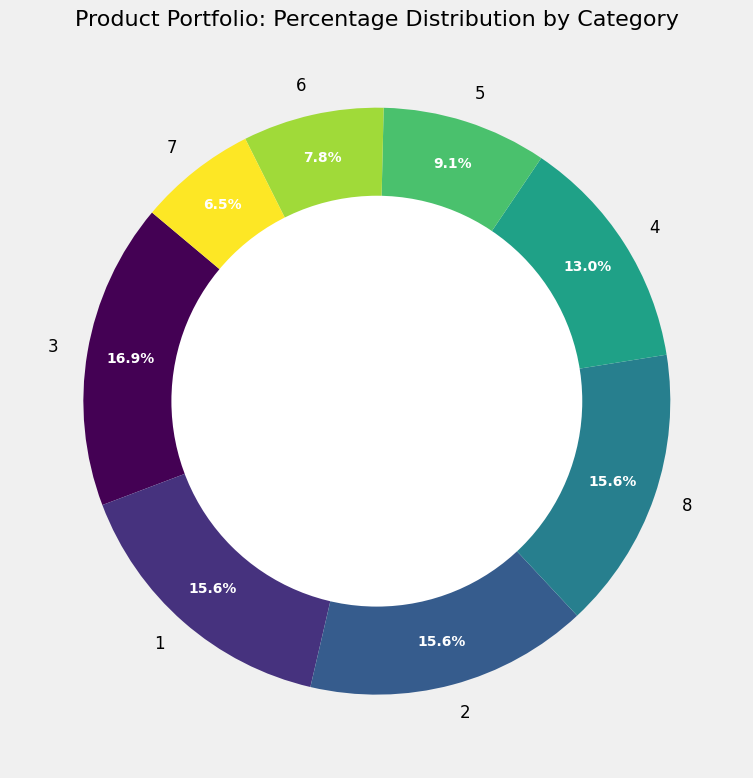

In [36]:
category_counts = df_cleaned['CategoryID'].value_counts()

with plt.style.context("fivethirtyeight"):
    plt.figure(figsize=(10, 8))
    
    wedges, texts, autotexts = plt.pie(
        category_counts, 
        labels=category_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        pctdistance=0.85,
        colors=plt.cm.viridis(np.linspace(0, 1, len(category_counts)))
    )

    plt.setp(autotexts, size=10, weight="bold", color="white")
    plt.setp(texts, size=12)

    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('Product Portfolio: Percentage Distribution by Category', fontsize=16)
    plt.tight_layout()
    plt.savefig('category_distribution_pie.png')
    plt.show()

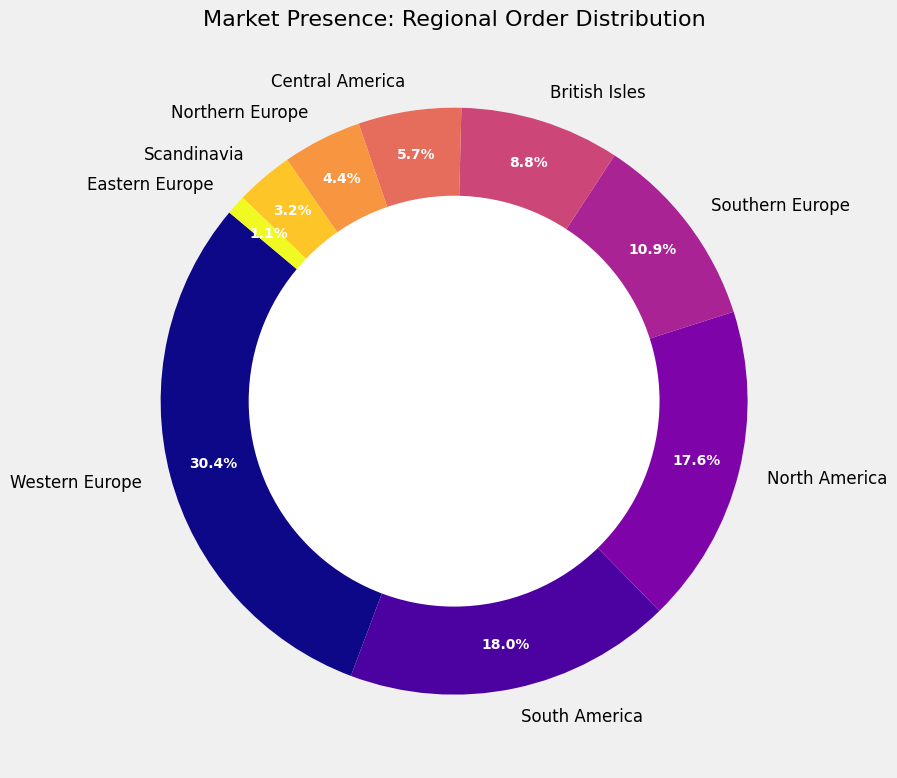

In [37]:
region_counts = df_cleaned['Region'].value_counts()

with plt.style.context("fivethirtyeight"):
    plt.figure(figsize=(10, 8))
    
    wedges, texts, autotexts = plt.pie(
        region_counts, 
        labels=region_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        pctdistance=0.85,
        colors=plt.cm.plasma(np.linspace(0, 1, len(region_counts)))
    )

    plt.setp(autotexts, size=10, weight="bold", color="white")
    plt.setp(texts, size=12)

    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('Market Presence: Regional Order Distribution', fontsize=16)
    plt.tight_layout()
    plt.savefig('region_distribution_pie.png')
    plt.show()